1. Importing libraries

In [218]:
#%pip install --upgrade pandas pyjanitor

In [219]:
import pandas as pd
import janitor
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno


2. Loading dataset as dataframe

In [ ]:
df = pd.read_csv('../data/Churn_Modelling.csv').clean_names()
#df.head(20)

3. Counting nulls by column

In [221]:
total_nulls = df.isnull().sum()
total_nulls

rownumber           0
customerid          0
surname             1
creditscore         1
geography          41
gender              1
age                79
tenure              1
balance             0
numofproducts       0
hascrcard           0
isactivemember      0
estimatedsalary     0
exited              0
dtype: int64

4. Counting nulls by row

In [222]:
nulls_row = df[df.isnull().sum(axis = 1) > 0] # Dataframe only with missing values
series_null = nulls_row.isna().sum(axis = 1) # series counting rows with missings values and quantity of missing values on each row.
print(series_null)

9        1
19       1
29       1
39       1
49       1
        ..
9959     2
9989     2
9999     2
10014    2
10016    2
Length: 99, dtype: int64


5. Percentage of nulls by column

In [223]:
null_percentage = (total_nulls / len(df)) * 100
null_percentage

rownumber          0.000000
customerid         0.000000
surname            0.009979
creditscore        0.009979
geography          0.409141
gender             0.009979
age                0.788344
tenure             0.009979
balance            0.000000
numofproducts      0.000000
hascrcard          0.000000
isactivemember     0.000000
estimatedsalary    0.000000
exited             0.000000
dtype: float64

6. Null reporting

In [224]:
report = pd.DataFrame({'Variable': total_nulls.index,'#_Nulls':total_nulls.values,'%':null_percentage.values})
report = report[report['#_Nulls'] > 0].sort_values(by = '#_Nulls', ascending=False)
report.to_csv('../reports/nulls_report.csv', index=False)
report

,Variable,#_Nulls,%
6,age,79,0.788344
4,geography,41,0.409141
3,creditscore,1,0.009979
2,surname,1,0.009979
5,gender,1,0.009979
7,tenure,1,0.009979


7. Nulls chart by column

/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


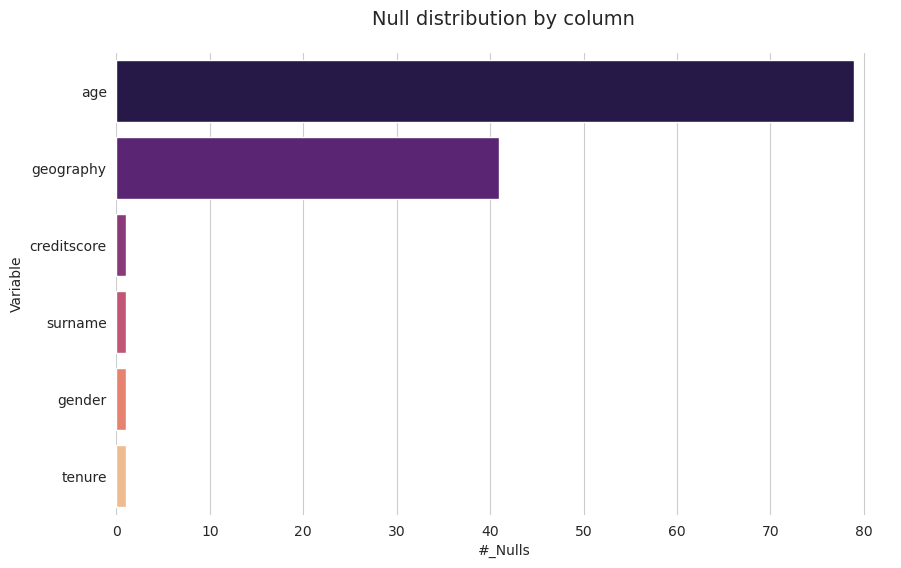

In [225]:
if report.empty:
    print("No nulls to show in a figure")
else:
    plt.figure(figsize = (10,6))
    sns.set_style("whitegrid")
    plot = sns.barplot(data = report, x = '#_Nulls', y = 'Variable', palette = 'magma')
    plt.title('Null distribution by column', fontsize = 14, pad = 20 )
    sns.despine(left = True, bottom = True)
    plt.savefig('../graphs/null_dist.png', dpi = 300)
    plt.show()
    

8. Nulls chart by row ocurrence

/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


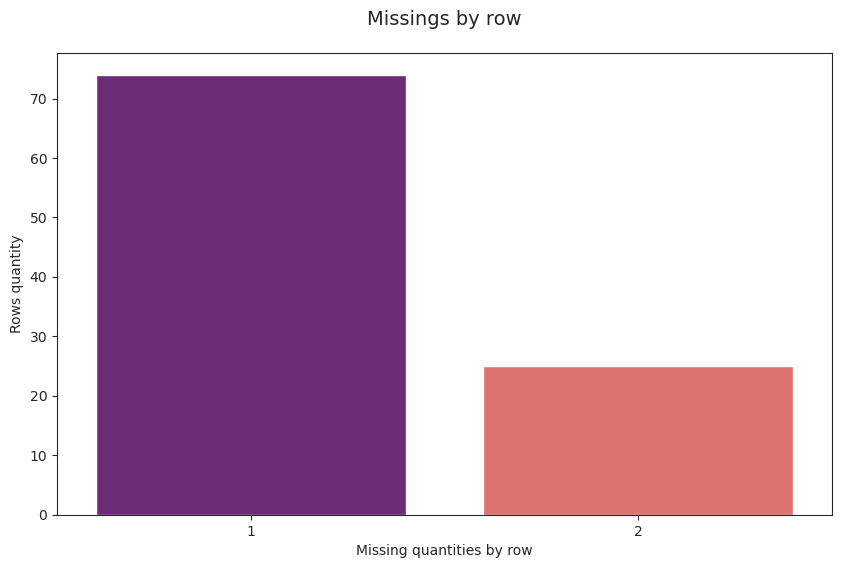

In [226]:
plt.figure(figsize = (10,6))
sns.set_style("ticks")
gr = sns.countplot(x = series_null, palette = 'magma')
plt.title('Missings by row', fontsize = 14, pad = 20 )
plt.xlabel('Missing quantities by row')
plt.ylabel('Rows quantity')
#gr.set_yticks(np.arange(0,101,5))
#sns.despine(left = True, bottom = True)
plt.savefig('../graphs/missing_dist.png', dpi = 300)
plt.show()

9. Heatmap, useful to find correlation between missing values

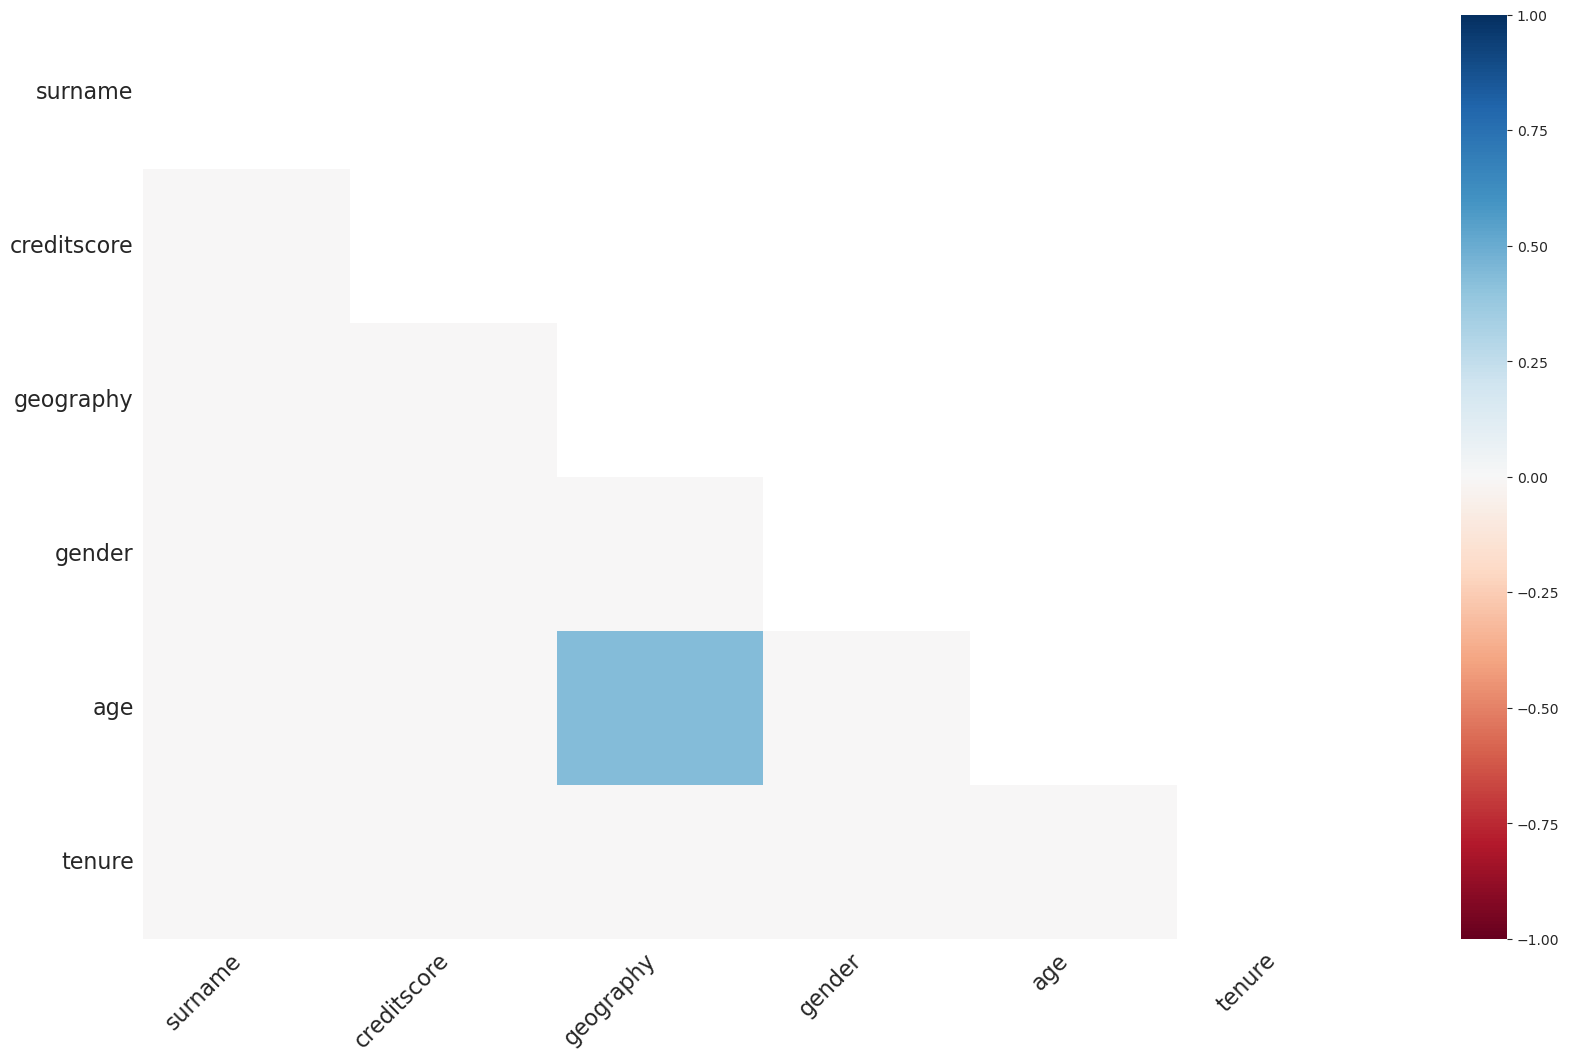

In [227]:
msno.heatmap(df, labels = False)
plt.savefig('../graphs/missing_heatmap.png', dpi = 300)
plt.show()

10. Matrix of missing values, it works for evaluating trends on missing value.

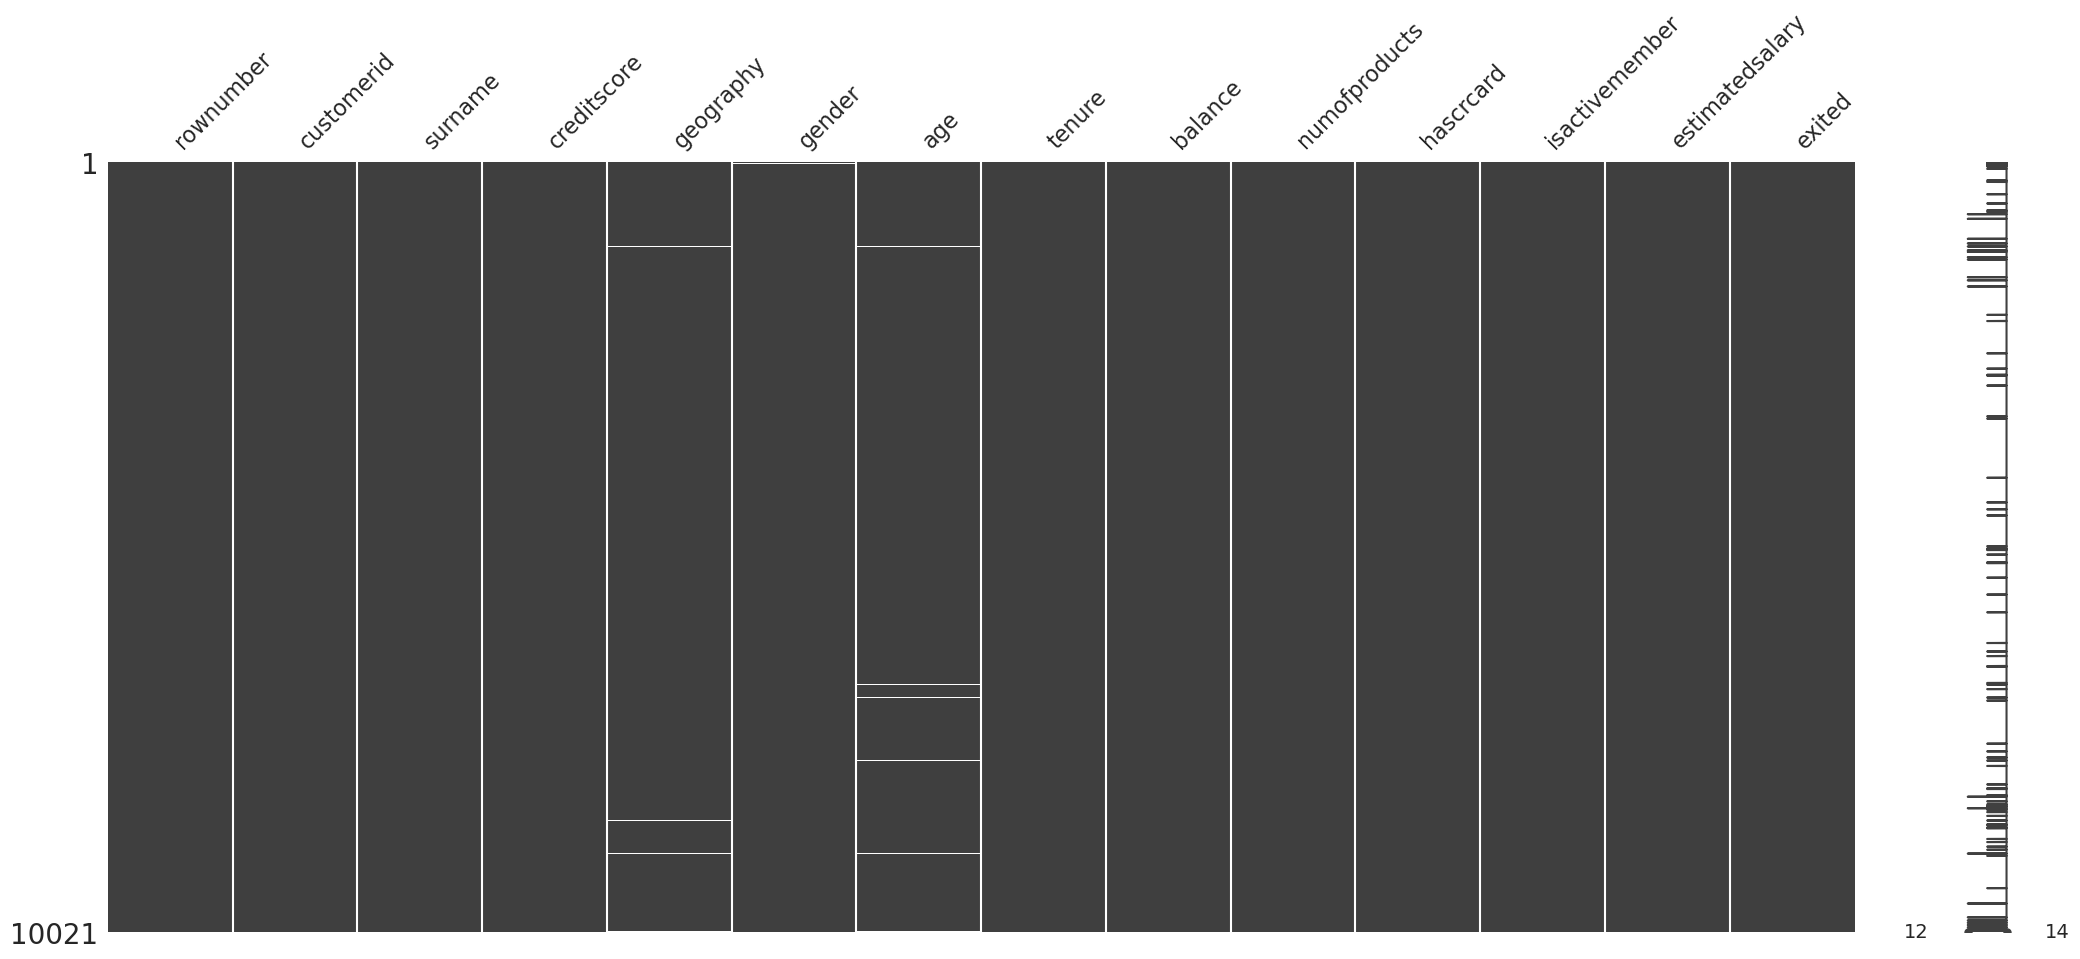

In [228]:
msno.matrix(df)
plt.savefig('../graphs/missing_matrix.png', dpi = 300)
plt.show()

11. Dendrogram of missing values, it works for evaluating trends on missing value.

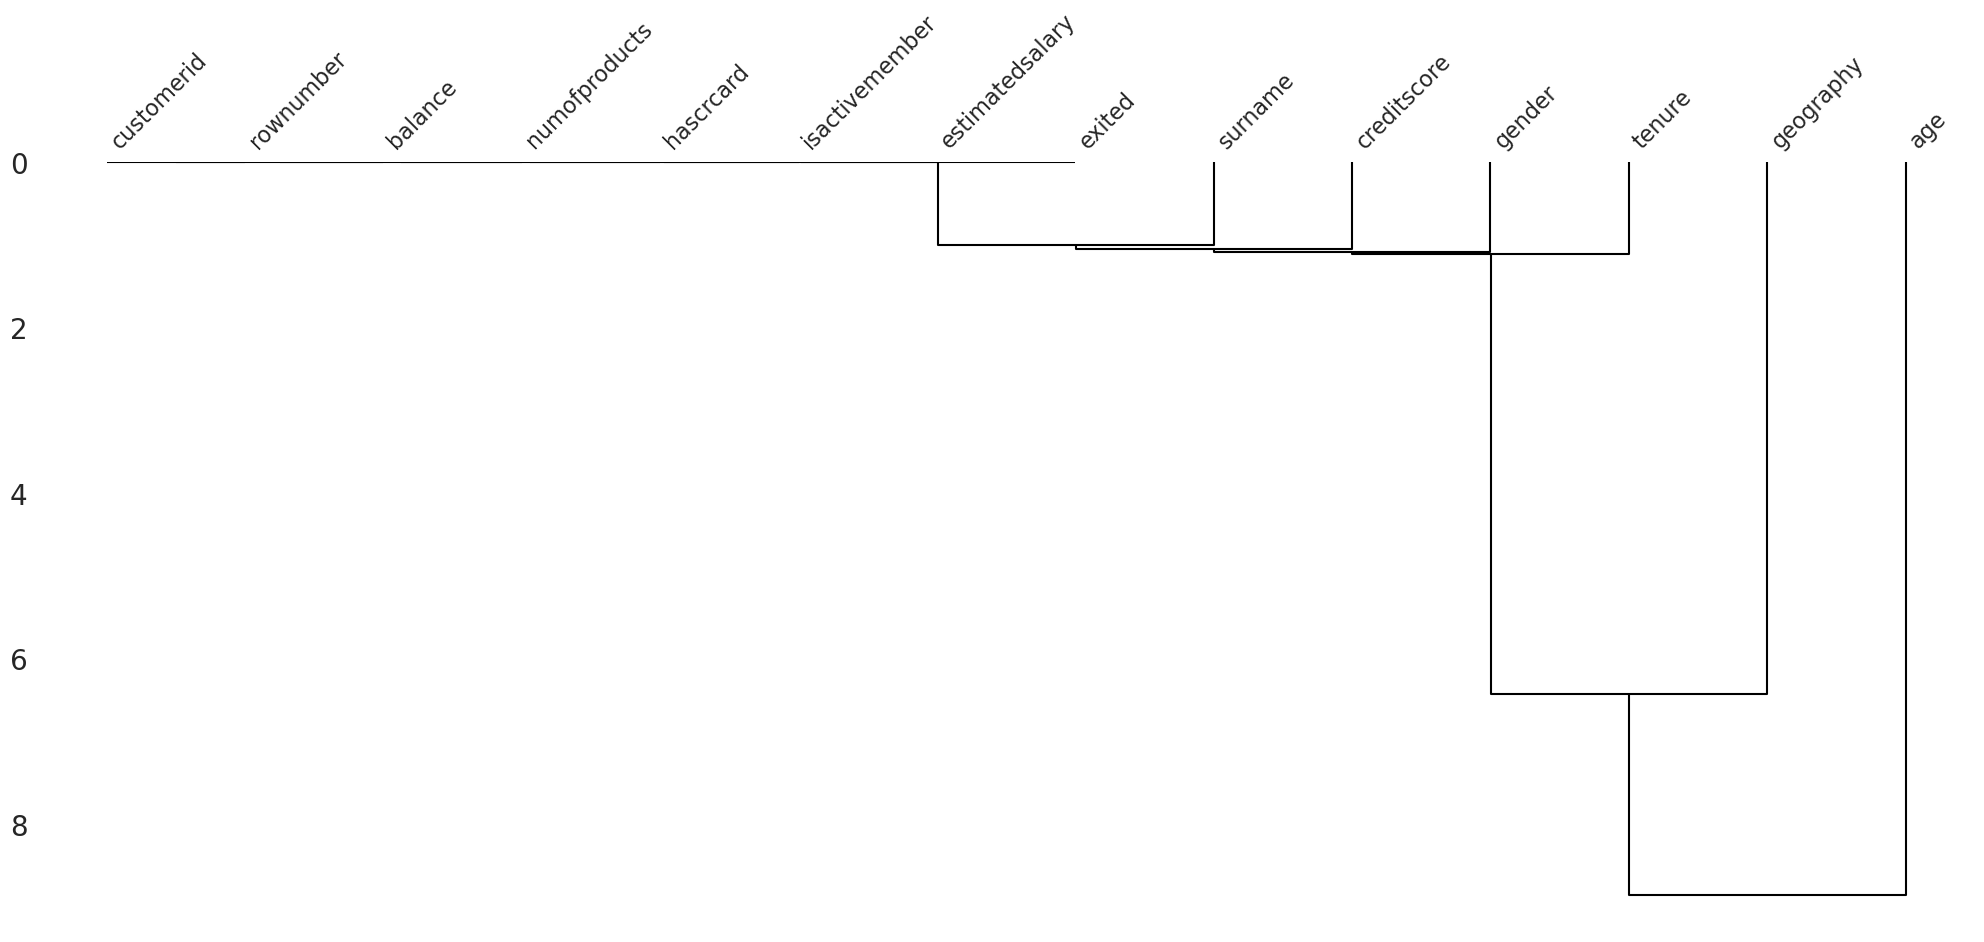

In [229]:
msno.dendrogram(df)
plt.savefig('../graphs/missing_dendro.png', dpi = 300)
plt.show()

12. Duplicated columns review, if exist, then proceed to remove them.
- Removing single missing, less than 5% and MCAR missing completely at random.-

In [230]:
duplicados = df['customerid'].duplicated().sum()
threshold = (len(df)-duplicados) *0.005 # For this case we use a 0.5 % criteria instead of 5%.

dicc = []
for name, value in total_nulls.items():
      if 0 < value < threshold:
        dicc.append(name)  
df_1 = df.dropna(subset=dicc) 

In [231]:
duplicated_report = pd.DataFrame({'index': df_1['rownumber'], 'duplicate': df_1['customerid'] })
duplicated_report = duplicated_report[duplicated_report['duplicate'].duplicated()]
duplicated_report.to_csv('../reports/duplicated_report.csv', index = False)

In [232]:
df_2= df_1['customerid'].unique()
len(df_2)

9957

13. Imputation process.

In [233]:
#df.to_csv('../data/Modelling_nulls.csv')